# Python File Opening Modes: `a`, `a+`, `w`, `w+`, and `r+`

**Topics covered:** file pointer position · truncation behaviour · read/write permissions · common pitfalls and fixes

Python's built-in `open()` function provides five core modes for file manipulation. Misunderstanding their differences is one of the most common sources of silent data loss and confusing bugs in Python file I/O. This notebook walks through each mode with **real, runnable file operations** so that the behaviour is observed directly, not just described.

**Roadmap**

1. The file pointer: the one concept that explains everything
2. Mode-by-mode analysis with live demonstrations
3. Truncation behaviour, illustrated
4. A complete feature comparison
5. Common pitfalls and their fixes
6. A decision guide for choosing the right mode


## 1. The File Pointer

Every open file has an internal cursor called the **file pointer**, which tracks the current read/write position. Every read or write operation advances the pointer by the number of bytes processed.

The `+` suffix always **adds** the ability to both read and write — but it does **not** change where the pointer starts. That depends entirely on the base letter (`r`, `w`, or `a`). This is the single most common source of confusion among Python's file modes.

> **Key rule.** `+` adds read/write capability. The base letter (`a`, `w`, `r`) controls pointer position and truncation behaviour.

| Mode | Read | Write | Pointer start | Truncates existing content | If file is missing |
|---|---|---|---|---|---|
| `a` | No | Yes (append only) | End (EOF) | No | Creates it |
| `a+` | Yes | Yes (append only) | End (EOF) | No | Creates it |
| `w` | No | Yes | Start (SOF) | Yes | Creates it |
| `w+` | Yes | Yes | Start (SOF) | Yes | Creates it |
| `r+` | Yes | Yes | Start (SOF) | No | Raises `FileNotFoundError` |


In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np

work_dir = "file_mode_demo"
os.makedirs(work_dir, exist_ok=True)

def fresh_path(name):
    # helper to build a path inside the demo working directory
    return os.path.join(work_dir, name)


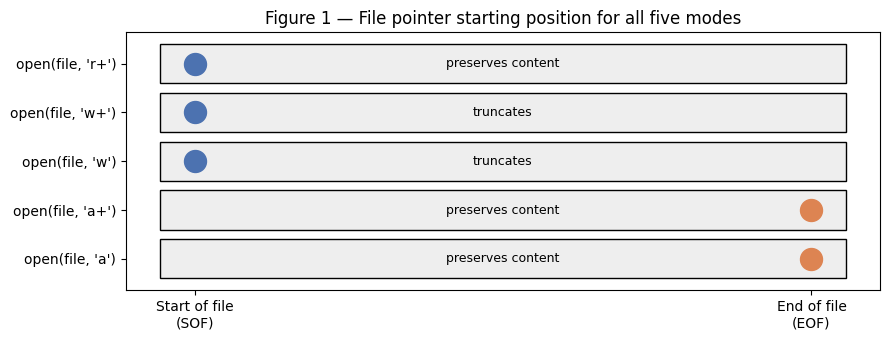

In [2]:
# Visualise where the pointer starts for each mode (Figure 1 in the source paper)
modes = ["a", "a+", "w", "w+", "r+"]
pointer_start = ["EOF", "EOF", "SOF", "SOF", "SOF"]
truncates = [False, False, True, True, False]

fig, ax = plt.subplots(figsize=(9, 3.5))
colors = ["#DD8452" if p == "EOF" else "#4C72B0" for p in pointer_start]
y_pos = np.arange(len(modes))
ax.barh(y_pos, [1]*len(modes), color="#EEEEEE", edgecolor="black")
for i, (mode, pstart, trunc) in enumerate(zip(modes, pointer_start, truncates)):
    marker_x = 0.95 if pstart == "EOF" else 0.05
    ax.scatter([marker_x], [i], s=250, color=colors[i], zorder=3,
               label=pstart if i == 0 or pstart not in pointer_start[:i] else None)
    trunc_text = "truncates" if trunc else "preserves content"
    ax.text(0.5, i, trunc_text, ha="center", va="center", fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels([f"open(file, '{m}')" for m in modes])
ax.set_xticks([0.05, 0.95])
ax.set_xticklabels(["Start of file\n(SOF)", "End of file\n(EOF)"])
ax.set_xlim(-0.05, 1.05)
ax.set_title("Figure 1 — File pointer starting position for all five modes")
plt.tight_layout()
plt.show()


## 2. Mode-by-Mode Analysis

### 2.1 Append mode: `a`

* Writes data **only** at the end of the file, regardless of any `seek()` calls.
* Existing content is always preserved.
* The file is created automatically if it does not exist.
* Reading is **not** allowed.
* Best use: log files, audit trails, append-only data streams.

In [3]:
log_path = fresh_path("app.log")

# Start clean for the demonstration
if os.path.exists(log_path):
    os.remove(log_path)

with open(log_path, "a") as f:
    f.write("2026-06-01 INFO  service started\n")

with open(log_path, "a") as f:
    f.seek(0)                      # seek is accepted, but...
    f.write("2026-06-02 INFO  health check OK\n")   # ...write still lands at EOF

with open(log_path, "r") as f:
    print(f.read())


2026-06-01 INFO  service started
2026-06-02 INFO  health check OK



Notice that calling `f.seek(0)` before writing had **no effect** — append mode always writes at the end, which is exactly why it is safe for logging: even a misplaced `seek()` cannot accidentally overwrite earlier entries.

### 2.2 Append + read: `a+`

* Combines read capability with append-only writing.
* **Critical:** the pointer starts at EOF, so reading immediately after opening returns an empty string. You must call `f.seek(0)` first to read existing content.
* Writing always appends to the end regardless of where the pointer currently is.
* Best use: appending new records while occasionally reading existing ones.

In [4]:
with open(log_path, "a+") as f:
    first_read = f.read()                 # pointer starts at EOF -> empty!
    f.seek(0)
    full_read_after_seek = f.read()       # now we see everything
    f.write("2026-06-03 INFO  another entry\n")  # still appended at the end

print("Read immediately after opening 'a+' (pointer at EOF):", repr(first_read))
print()
print("Read after f.seek(0):")
print(full_read_after_seek)


Read immediately after opening 'a+' (pointer at EOF): ''

Read after f.seek(0):
2026-06-01 INFO  service started
2026-06-02 INFO  health check OK



### 2.3 Write mode: `w`

* **Warning:** immediately truncates the file to 0 bytes on opening — even before any write call happens.
* All previous content is permanently destroyed.
* Creates the file if it does not exist.
* Best use: creating new files or completely replacing existing content.

In [5]:
important_path = fresh_path("important_data.txt")

with open(important_path, "w") as f:
    f.write("version 1: this took a while to compute\n")

print("Before:")
with open(important_path) as f:
    print(f.read())

# A well-intentioned "small update" using the wrong mode:
with open(important_path, "w") as f:
    pass  # the file is already truncated, even though nothing was written yet!

print("After opening with 'w' and writing nothing:")
with open(important_path) as f:
    print(repr(f.read()), "<- the original content is gone")


Before:
version 1: this took a while to compute

After opening with 'w' and writing nothing:
'' <- the original content is gone


This is the single most damaging pitfall described in the paper: opening a file with `w` to "just add a line" silently destroys everything that was there before, the moment the file is opened — not when you write to it.

### 2.4 Write + read: `w+`

* Like `w`, it truncates the file immediately on opening.
* After writing, the pointer sits at the end of what was just written — calling `f.read()` immediately afterwards returns an empty string.
* Best use: creating and immediately reading back a temporary file within the same session.

In [6]:
scratch_path = fresh_path("scratch.txt")

with open(scratch_path, "w+") as f:
    f.write("Hello, temporary file!")
    empty_because_pointer_at_end = f.read()     # pointer is at EOF right after writing
    f.seek(0)
    correct_read = f.read()                     # now this works

print("f.read() right after writing (no seek):", repr(empty_because_pointer_at_end))
print("f.read() after f.seek(0):              ", repr(correct_read))


f.read() right after writing (no seek): ''
f.read() after f.seek(0):               'Hello, temporary file!'


### 2.5 Read + write: `r+`

* Preserves all existing content — does **not** truncate.
* Raises `FileNotFoundError` if the file does not already exist (unlike `a`, `w`, `a+`, `w+`, which all create the file).
* Writing in `r+` overwrites existing bytes **in place** — it does not insert or shift the remaining content.
* Best use: editing part of an existing file without disturbing the rest.

In [7]:
record_path = fresh_path("record.txt")
with open(record_path, "w") as f:
    f.write("AAAAAAAAAA")   # 10 characters, used as a baseline

with open(record_path, "r+") as f:
    f.seek(2)
    f.write("XYZ")          # overwrites 3 bytes in place, starting at position 2

with open(record_path) as f:
    print("After in-place edit with r+:", f.read())

try:
    with open(fresh_path("does_not_exist.txt"), "r+") as f:
        pass
except FileNotFoundError as e:
    print("\\nOpening a missing file with 'r+' raises:", repr(e))


After in-place edit with r+: AAXYZAAAAA
\nOpening a missing file with 'r+' raises: FileNotFoundError(2, 'No such file or directory')


## 3. Truncation Behaviour, Illustrated

The figure below summarises the central distinction of this paper in one picture: `w`/`w+` destroy existing content the instant the file is opened, while `a`/`a+` always preserve it and add new data strictly after it.

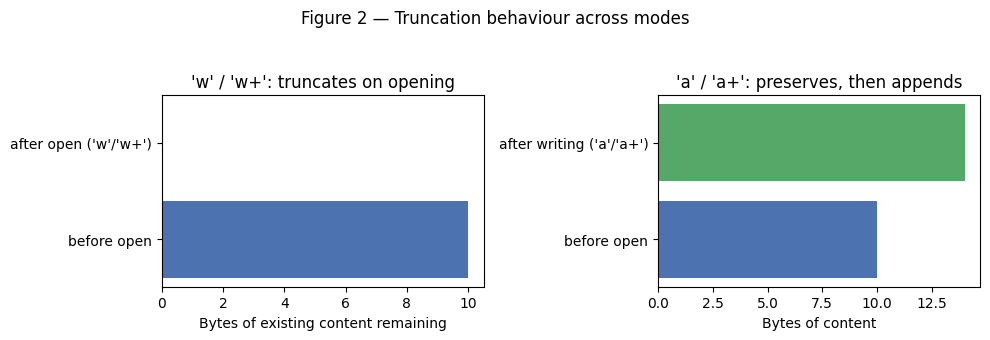

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))

# Left: w / w+ truncates on open
axes[0].barh(["before open", "after open ('w'/'w+')"], [10, 0], color=["#4C72B0", "#C44E52"])
axes[0].set_title("'w' / 'w+': truncates on opening")
axes[0].set_xlabel("Bytes of existing content remaining")

# Right: a / a+ preserves and appends
axes[1].barh(["before open", "after writing ('a'/'a+')"], [10, 14], color=["#4C72B0", "#55A868"])
axes[1].set_title("'a' / 'a+': preserves, then appends")
axes[1].set_xlabel("Bytes of content")

fig.suptitle("Figure 2 — Truncation behaviour across modes", y=1.05)
plt.tight_layout()
plt.show()


## 4. Complete Feature Comparison

The matrix below (Figure 3 in the source paper) compresses the entire mode comparison into a single visual: only `a` and `a+` start at the end of the file; only `w` and `w+` truncate; only `r+` requires the file to already exist.

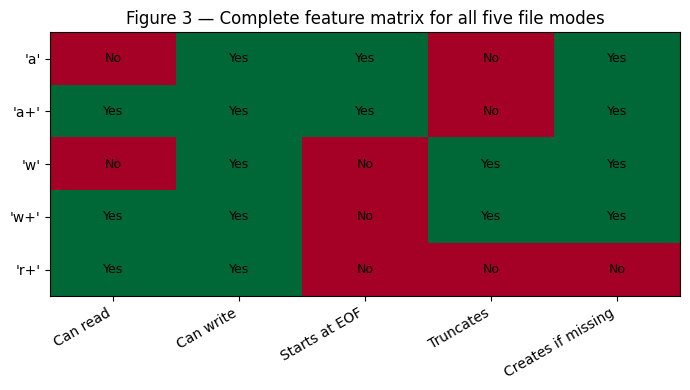

In [9]:
features = ["Can read", "Can write", "Starts at EOF", "Truncates", "Creates if missing"]
mode_feature_matrix = np.array([
    [0, 1, 1, 0, 1],   # a
    [1, 1, 1, 0, 1],   # a+
    [0, 1, 0, 1, 1],   # w
    [1, 1, 0, 1, 1],   # w+
    [1, 1, 0, 0, 0],   # r+
])

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(mode_feature_matrix, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(features)))
ax.set_xticklabels(features, rotation=30, ha="right")
ax.set_yticks(range(len(modes)))
ax.set_yticklabels([f"'{m}'" for m in modes])
for i in range(len(modes)):
    for j in range(len(features)):
        label = "Yes" if mode_feature_matrix[i, j] else "No"
        ax.text(j, i, label, ha="center", va="center", fontsize=9)
ax.set_title("Figure 3 — Complete feature matrix for all five file modes")
plt.tight_layout()
plt.show()


## 5. Common Pitfalls and Fixes

| Pitfall | Why it happens | Fix |
|---|---|---|
| Accidental data loss with `w` | `w` truncates the file immediately on opening, before any write call | Use `a` for appending; reserve `w` for intentional full replacement |
| Empty read after `w+` | The pointer sits at EOF right after a write | Call `f.seek(0)` before reading back what was just written |
| `r+` on a missing file | `r+` does not create files, unlike `a`, `w`, `a+`, `w+` | Use `w+` if the file may not exist and truncation is acceptable, or check `os.path.exists()` first |

Both pitfalls above were reproduced live in Sections 2.3 and 2.4 — they are not hypothetical, they are exactly what the code printed.

## 6. Decision Guide: Choosing the Right Mode

| Use case | Correct mode | Why |
|---|---|---|
| Append to a log file | `a` | Write-only at the end, no truncation |
| Read and append new records | `a+` | Read anywhere, write always appends |
| Replace the entire file | `w` | Truncates and rewrites from scratch |
| Create a temp file and read it back in the same session | `w+` | Create and read within one session |
| Edit part of an existing file | `r+` | In-place editing, no truncation, file must already exist |
| Read only, never write | `r` | Read-only — the safest option when no modification is intended |


In [10]:
def recommend_mode(need_write, need_read, file_might_be_missing, want_to_replace_entirely, want_to_append_only):
    # A tiny rule-based helper mirroring Figure 5's decision flowchart.
    if not need_write:
        return "r"
    if want_to_append_only:
        return "a+" if need_read else "a"
    if want_to_replace_entirely:
        return "w+" if need_read else "w"
    if file_might_be_missing:
        return "w+"   # accept truncation risk in exchange for auto-creation
    return "r+"        # edit in place, file must already exist


print(recommend_mode(need_write=True, need_read=False, file_might_be_missing=True,
                      want_to_replace_entirely=False, want_to_append_only=True))
print(recommend_mode(need_write=True, need_read=True, file_might_be_missing=False,
                      want_to_replace_entirely=False, want_to_append_only=False))
print(recommend_mode(need_write=False, need_read=True, file_might_be_missing=False,
                      want_to_replace_entirely=False, want_to_append_only=False))


a
r+
r


In [11]:
import shutil
shutil.rmtree(work_dir)   # tidy up the demonstration files created in this notebook


## 7. Conclusion

Python's five core file modes cover every common file I/O scenario, but only if the right one is chosen deliberately. The two rules worth memorising are:

1. **Never use `w` when you mean to append** — use `a` instead. `w` truncates on opening, regardless of what you intend to write.
2. **Always call `f.seek(0)` before reading back** content you just wrote in `w+` or `a+` mode — the pointer will otherwise be sitting at the end of the file.

In short: `a` = append-only. `a+` = append + read. `w` = write (destroys existing content). `w+` = write + read (also destroys existing content). `r+` = read + write on a file that must already exist, with no truncation. The `+` adds read capability; it never changes pointer position or truncation behaviour — that is always controlled by the base letter.

## References

1. Python Software Foundation. *Built-in Functions: `open()`.* Python 3 Documentation.
2. Python Software Foundation. *`io` — Core tools for working with streams.* Python 3 Library Reference.
3. Real Python. *Working with Files in Python.*
4. GeeksforGeeks. *File handling in Python.*
5. W3Schools. *Python File Open.*